# Predição de Casos e Surtos de Dengue em Jaboatão dos Guararapes: Uma Análise Comparativa entre Modelos Estatísticos, Técnicas Tree-Based e Arquitetura LSTM Multitarefa


---
## 0. Imports e configuração

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import callbacks as keras_callbacks

# módulos locais
import sys
sys.path.append('../src')
from metrics import f1_score, auc, mape, medape
from validation import bootstrap, validacao_cruzada_temporal

# modelos
from models.sarima import SARIMAModel
from models.random_forest import RandomForestModel
from models.lstm import (
    LSTMBidirectionalMultitaskHyperModel,
    LSTMHyperparameterTuner
)

np.random.seed(1)

DATA_PATH = "/Users/adeleborba/Desktop/dengue-jaboatao/data/processed/dengue_jaboatao_semanal_2018_2025_processed.parquet"
WINDOW_SIZE = 16  # janela de 16 semanas
N_SPLITS    = 3   
BOOTSTRAP_N = 1000


---
## 1. Carregamento e pré-processamento

In [ ]:
df = pd.read_parquet(DATA_PATH)

df['data_semana'] = pd.to_datetime(df['data_semana'])
df = df.sort_values('data_semana')
df = df.set_index('data_semana')

df['semana_ano'] = df.index.isocalendar().week
df['semana_sin'] = np.sin(2 * np.pi * df['semana_ano'] / 52)
df['semana_cos'] = np.cos(2 * np.pi * df['semana_ano'] / 52)

df['casos_lag1'] = df['casos'].shift(1)
df['casos_lag2'] = df['casos'].shift(2)


df['casos_log'] = np.log1p(df['casos'])
df['lag1_log']  = np.log1p(df['casos_lag1'])
df['lag2_log']  = np.log1p(df['casos_lag2'])

df['ano'] = df.index.year
df_treino = df[df['ano'] <= 2024]

scaler = MinMaxScaler()
scaler.fit(df_treino[['casos_log']])
df['casos_norm'] = scaler.transform(df[['casos_log']])

scaler_lag1 = MinMaxScaler()
scaler_lag1.fit(df_treino[['lag1_log']])
df['lag1_norm'] = scaler_lag1.transform(df[['lag1_log']])

scaler_lag2 = MinMaxScaler()
scaler_lag2.fit(df_treino[['lag2_log']])
df['lag2_norm'] = scaler_lag2.transform(df[['lag2_log']])

print(df.shape)
df.head()

(417, 16)


,casos,ano,populacao,incidencia,incidencia_norm,semana_ano,semana_sin,semana_cos,casos_lag1,casos_lag2,casos_log,lag1_log,lag2_log,casos_norm,lag1_norm,lag2_norm
data_semana,,,,,,,,,,,,,,,,
2018-01-07,5,2018,644231,40.358194,0.031437,1,0.120537,0.992709,NaN,NaN,1.791759,NaN,NaN,0.353044,NaN,NaN
2018-01-14,13,2018,644231,104.931306,0.081736,2,0.239316,0.970942,5.0,NaN,2.639057,1.791759,NaN,0.519993,0.353044,NaN
2018-01-21,8,2018,644231,64.573111,0.050299,3,0.354605,0.935016,13.0,5.0,2.197225,2.639057,1.791759,0.432936,0.519993,0.353044
2018-01-28,9,2018,644231,72.644750,0.056587,4,0.464723,0.885456,8.0,13.0,2.302585,2.197225,2.639057,0.453696,0.432936,0.519993
2018-02-04,9,2018,644231,72.644750,0.056587,5,0.568065,0.822984,9.0,8.0,2.302585,2.302585,2.197225,0.453696,0.453696,0.432936


---
## 2. Split 80/20 — treino (2018–2024) · teste (2025)

In [ ]:
df['ano'] = df.index.year
df_train = df[df['ano'] <= 2024]
limiar = df_train['casos'].quantile(0.75)
df['surto'] = (df['casos'] > limiar).astype(int)

# SARIMA 
y_train_s = df.loc[df['ano'] <= 2024, 'casos']
y_test_s  = df.loc[df['ano'] == 2025, 'casos']

# Random Forest 
RF_FEATURES = ['casos_lag1', 'casos_lag2', 'semana_sin', 'semana_cos']
X_train_rf = df.loc[df['ano'] <= 2024, RF_FEATURES].values
X_test_rf  = df.loc[df['ano'] == 2025, RF_FEATURES].values
y_train_rf = df.loc[df['ano'] <= 2024, 'surto'].values
y_test_rf  = df.loc[df['ano'] == 2025, 'surto'].values

# LSTM 
LSTM_FEATURES = ['casos_norm', 'semana_sin', 'semana_cos',
                  'lag1_norm', 'lag2_norm']

def criar_janelas(data: pd.DataFrame, w: int = 4):
    X, y_reg, y_class = [], [], []
    for i in range(w, len(data)):
        X.append(data[LSTM_FEATURES].iloc[i-w:i].values.astype(np.float32))
        y_reg.append(data['casos_norm'].iloc[i])
        y_class.append(data['surto'].iloc[i])
    return np.array(X), np.array(y_reg), np.array(y_class)


X_lstm, y_reg_lstm, y_class_lstm = criar_janelas(df, w=WINDOW_SIZE)

nan_mask = np.isnan(X_lstm).any(axis=(1,2))

X_lstm       = X_lstm[~nan_mask]
y_reg_lstm   = y_reg_lstm[~nan_mask]
y_class_lstm = y_class_lstm[~nan_mask]

n_treino    = len(df[df['ano'] <= 2024]) - WINDOW_SIZE
n_removidas = nan_mask[:n_treino].sum()
split_lstm  = n_treino - n_removidas

X_train_lstm,  X_test_lstm  = X_lstm[:split_lstm],        X_lstm[split_lstm:]
y_reg_train,   y_reg_test   = y_reg_lstm[:split_lstm],    y_reg_lstm[split_lstm:]
y_class_train, y_class_test = y_class_lstm[:split_lstm],  y_class_lstm[split_lstm:]

print(f"SARIMA   → treino: {len(y_train_s)} | teste: {len(y_test_s)}")
print(f"RF       → treino: {len(X_train_rf)} | teste: {len(X_test_rf)}")
print(f"LSTM     → treino: {len(X_train_lstm)} | teste: {len(X_test_lstm)}")

Amostras removidas por NaN: 2
SARIMA   → treino: 365 | teste: 52
RF       → treino: 365 | teste: 52
LSTM     → treino: 347 | teste: 52
NaN em X_train_lstm: 0
NaN em X_test_lstm:  0


---
## 3. SARIMA

### 3.1 Validação cruzada temporal

In [97]:
print("SARIMA — Validação cruzada temporal (3 folds)")

folds_s = validacao_cruzada_temporal(y_train_s, y=None, n_splits=N_SPLITS)
scores_sarima_cv = []

for fold in folds_s:
    yf_tr = y_train_s.iloc[fold['treino']]
    yf_te = y_train_s.iloc[fold['teste']]

    sarima_cv = SARIMAModel(order=(2,1,2), seasonal_order=(0,1,1,52))
    sarima_cv.build(yf_tr)
    yf_pred = sarima_cv.predict(steps=len(yf_te))

    score = mape(yf_te.values, yf_pred)
    scores_sarima_cv.append(score)
    print(f"  Fold {fold['fold']}: MAPE = {score:.2f}%")

print(f"\nMAPE médio CV: {np.mean(scores_sarima_cv):.2f}% ± {np.std(scores_sarima_cv):.2f}%")

SARIMA — Validação cruzada temporal (3 folds)
  Fold 1: MAPE = 726.66%
  Fold 2: MAPE = 87.48%
  Fold 3: MAPE = 123.55%

MAPE médio CV: 312.56% ± 293.18%


### 3.2 Treino final e previsão

In [98]:
sarima = SARIMAModel(order=(2,1,2), seasonal_order=(0,1,1,52))
sarima.build(y_train_s)
y_pred_s = sarima.predict(steps=len(y_test_s))

print(f"MAPE  : {mape(y_test_s.values, y_pred_s):.2f}%")
print(f"MedAPE: {medape(y_test_s.values, y_pred_s):.2f}%")

MAPE  : 76.95%
MedAPE: 68.93%


### 3.3 Bootstrap — intervalos de confiança

In [99]:
ic_mape_s   = bootstrap(y_test_s.values, y_pred_s, mape,   n_iterations=BOOTSTRAP_N)
ic_medape_s = bootstrap(y_test_s.values, y_pred_s, medape, n_iterations=BOOTSTRAP_N)

print(f"MAPE   IC 95%: {ic_mape_s['media']:.2f}%  [{ic_mape_s['ic_inferior']:.2f}%, {ic_mape_s['ic_superior']:.2f}%]")
print(f"MedAPE IC 95%: {ic_medape_s['media']:.2f}% [{ic_medape_s['ic_inferior']:.2f}%, {ic_medape_s['ic_superior']:.2f}%]")

MAPE   IC 95%: 77.13%  [62.17%, 98.31%]
MedAPE IC 95%: 68.32% [55.69%, 81.49%]


### 3.4 Visualização

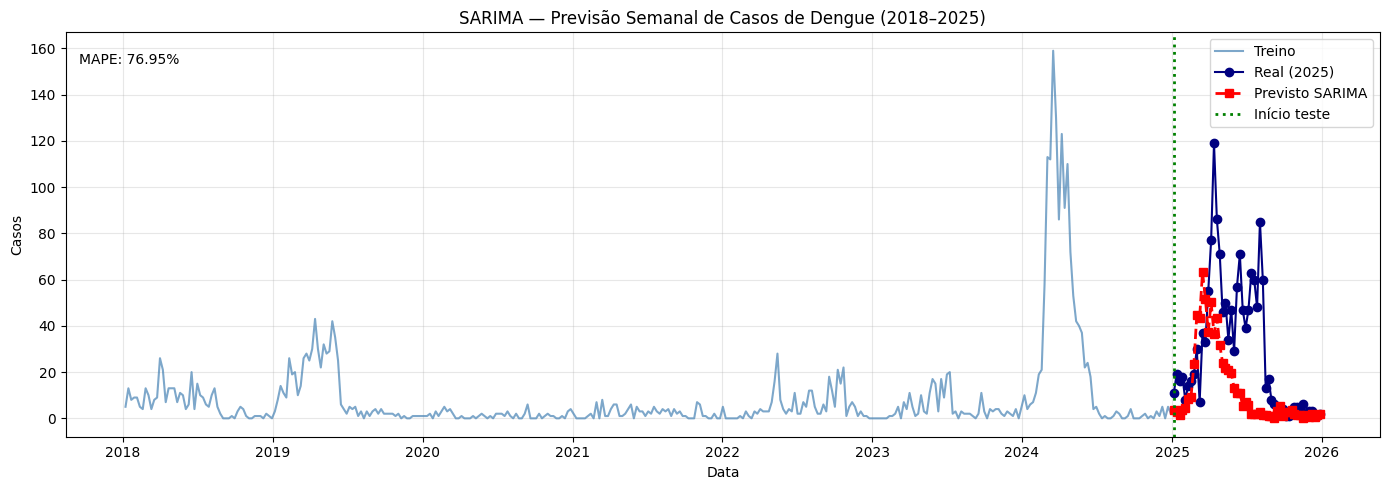

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_train_s.index, y_train_s.values, label='Treino', color='steelblue', alpha=0.7)

ax.plot(y_test_s.index, y_test_s.values, label='Real (2025)', color='navy', marker='o')

ax.plot(y_test_s.index, y_pred_s, label='Previsto SARIMA', color='red', marker='s', linestyle='--', linewidth=2)

ax.axvline(y_test_s.index[0], color='green', linestyle=':', linewidth=2, label='Início teste')

mape_val = mape(y_test_s.values, y_pred_s)
ax.text(0.01, 0.95, f"MAPE: {mape_val:.2f}%",
        transform=ax.transAxes,
        fontsize=10, verticalalignment='top')

ax.set_title('SARIMA — Previsão Semanal de Casos de Dengue (2018–2025)')
ax.set_xlabel('Data')
ax.set_ylabel('Casos')

ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Random Forest

### 4.1 Validação cruzada temporal

In [101]:
print("Random Forest — Validação cruzada temporal (3 folds)")

folds_rf = validacao_cruzada_temporal(X_train_rf, y=None, n_splits=N_SPLITS)
scores_f1_cv, scores_auc_cv = [], []

for fold in folds_rf:
    Xf_tr = X_train_rf[fold['treino']]
    Xf_te = X_train_rf[fold['teste']]
    yf_tr = y_train_rf[fold['treino']]
    yf_te = y_train_rf[fold['teste']]

    rf_cv = RandomForestModel(n_estimators=100, max_depth=3)
    rf_cv.build(Xf_tr, yf_tr)
    yf_pred      = rf_cv.predict(Xf_te)
    yf_pred_prob = rf_cv.predict_proba(Xf_te)

    scores_f1_cv.append(f1_score(yf_te, yf_pred))
    scores_auc_cv.append(auc(yf_te, yf_pred_prob))
    print(f"  Fold {fold['fold']}: F1={scores_f1_cv[-1]:.3f} | AUC={scores_auc_cv[-1]:.3f}")

print(f"\nF1  médio CV: {np.mean(scores_f1_cv):.3f} ± {np.std(scores_f1_cv):.3f}")
print(f"AUC médio CV: {np.mean(scores_auc_cv):.3f} ± {np.std(scores_auc_cv):.3f}")

Random Forest — Validação cruzada temporal (3 folds)
  Fold 1: F1=0.053 | AUC=0.900
  Fold 2: F1=0.476 | AUC=0.888
  Fold 3: F1=0.727 | AUC=0.902

F1  médio CV: 0.419 ± 0.278
AUC médio CV: 0.897 ± 0.006


### 4.2 Treino final e previsão

In [102]:
rf = RandomForestModel(n_estimators=100, max_depth=3)
rf.build(X_train_rf, y_train_rf)

y_pred_rf      = rf.predict(X_test_rf)
y_pred_rf_prob = rf.predict_proba(X_test_rf)

print(f"F1 : {f1_score(y_test_rf, y_pred_rf):.3f}")
print(f"AUC: {auc(y_test_rf, y_pred_rf_prob):.3f}")

F1 : 0.923
AUC: 0.940


### 4.3 Bootstrap — intervalos de confiança

In [103]:
ic_f1_rf  = bootstrap(y_test_rf, y_pred_rf,      f1_score, n_iterations=BOOTSTRAP_N, classificacao=True)
ic_auc_rf = bootstrap(y_test_rf, y_pred_rf_prob,  auc,      n_iterations=BOOTSTRAP_N, classificacao=True)

print(f"F1  IC 95%: {ic_f1_rf['media']:.3f}  [{ic_f1_rf['ic_inferior']:.3f}, {ic_f1_rf['ic_superior']:.3f}]")
print(f"AUC IC 95%: {ic_auc_rf['media']:.3f} [{ic_auc_rf['ic_inferior']:.3f}, {ic_auc_rf['ic_superior']:.3f}]")

F1  IC 95%: 0.924  [0.847, 0.984]
AUC IC 95%: 0.939 [0.830, 1.000]


### 4.4 Visualização

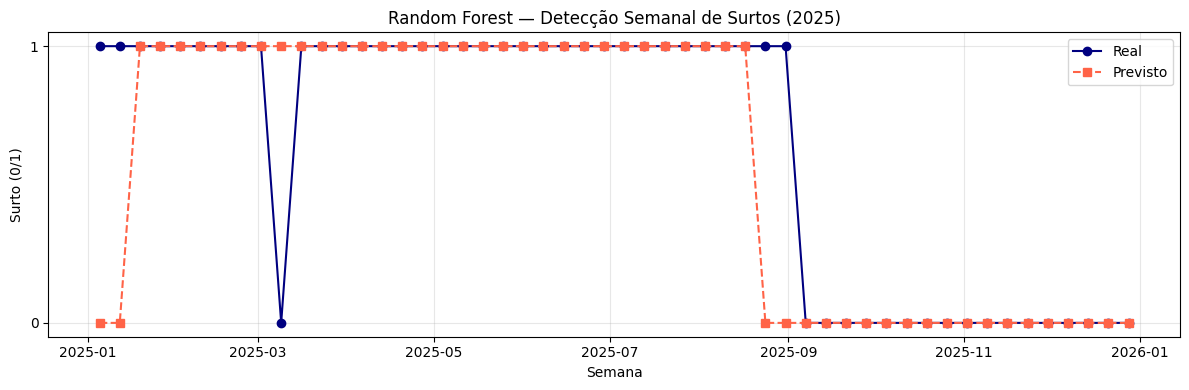

In [104]:
test_index = df.loc[df['ano'] == 2025].index

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test_index, y_test_rf,  label='Real',     marker='o', color='navy')
ax.plot(test_index, y_pred_rf,  label='Previsto', marker='s', linestyle='--', color='tomato')
ax.set_title('Random Forest — Detecção Semanal de Surtos (2025)')
ax.set_xlabel('Semana')
ax.set_ylabel('Surto (0/1)')
ax.set_yticks([0, 1])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



---
## 5. LSTM Multitarefa Bidirecional

### 5.1 Tuning de hiperparâmetros (Keras Tuner)

In [ ]:
hypermodel = LSTMBidirectionalMultitaskHyperModel(
    window_size=WINDOW_SIZE,
    num_features=5,   # casos_norm, semana_sin, semana_cos, lag1_norm, lag2_norm
    pred_steps=1
)

tuner = LSTMHyperparameterTuner(
    hypermodel=hypermodel,
    x_train=X_train_lstm,
    y_train_class=y_class_train,
    y_train_regress=y_reg_train,
    seed=42,
    epochs_tuning=50,
    max_trials=30,
    project_name="dengue_jaboatao_lstm_16semanas"
)


best_lstm = tuner.tune(save_path="best_lstm_jaboatao.keras")

Trial 30 Complete [00h 00m 18s]
val_loss: 0.2243940681219101

Best val_loss So Far: 0.21096137166023254
Total elapsed time: 00h 09m 54s
[LSTMHyperparameterTuner] Melhor modelo salvo em: best_lstm_jaboatao.keras
Tuning concluído.


### 5.2 Validação cruzada temporal

In [ ]:
print("LSTM — Validação cruzada temporal (3 folds)")

folds_lstm = validacao_cruzada_temporal(X_train_lstm, y=None, n_splits=N_SPLITS)
scores_mape_cv, scores_f1_cv_lstm, scores_auc_cv_lstm = [], [], []

cb_list = [
    keras_callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras_callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, verbose=0)
]

for fold in folds_lstm:
    Xf_tr      = X_train_lstm[fold['treino']]
    Xf_te      = X_train_lstm[fold['teste']]
    yf_reg_tr  = y_reg_train[fold['treino']]
    yf_reg_te  = y_reg_train[fold['teste']]
    yf_cl_tr   = y_class_train[fold['treino']]
    yf_cl_te   = y_class_train[fold['teste']]

    from tensorflow.keras.models import clone_model
    model_cv = clone_model(best_lstm)
    model_cv.compile(
        optimizer='adam',
        loss={
            'classification': 'binary_crossentropy',
            'regression':     'mean_absolute_error'   # MAE em vez de MSE
        },
        loss_weights={
            'classification': 1.0,
            'regression':     2.0   
        },
        metrics={'classification': 'accuracy', 'regression': 'mae'}
    )
    model_cv.fit(
        Xf_tr,
        {'classification': yf_cl_tr, 'regression': yf_reg_tr},
        epochs=50, batch_size=8, verbose=0, callbacks=cb_list
    )

    preds = model_cv.predict(Xf_te, verbose=0)

    yf_reg_pred = np.expm1(scaler.inverse_transform(preds[1])).flatten()
    yf_cl_pred   = (preds[0].flatten() > 0.5).astype(int)
    yf_reg_orig = np.expm1(scaler.inverse_transform(yf_reg_te.reshape(-1,1))).flatten()

    scores_mape_cv.append(mape(yf_reg_orig, yf_reg_pred))
    scores_f1_cv_lstm.append(f1_score(yf_cl_te, yf_cl_pred))
    scores_auc_cv_lstm.append(auc(yf_cl_te, preds[0].flatten()))
    print(f"  Fold {fold['fold']}: MAPE={scores_mape_cv[-1]:.1f}% | F1={scores_f1_cv_lstm[-1]:.3f} | AUC={scores_auc_cv_lstm[-1]:.3f}")

print(f"\nMAPE médio CV : {np.mean(scores_mape_cv):.1f}% ± {np.std(scores_mape_cv):.1f}%")
print(f"F1   médio CV : {np.mean(scores_f1_cv_lstm):.3f} ± {np.std(scores_f1_cv_lstm):.3f}")
print(f"AUC  médio CV : {np.mean(scores_auc_cv_lstm):.3f} ± {np.std(scores_auc_cv_lstm):.3f}")

LSTM — Validação cruzada temporal (3 folds)
  Fold 1: MAPE=196.1% | F1=0.053 | AUC=0.918
  Fold 2: MAPE=79.1% | F1=0.125 | AUC=0.671
  Fold 3: MAPE=63.9% | F1=0.737 | AUC=0.907

MAPE médio CV : 113.0% ± 59.1%
F1   médio CV : 0.305 ± 0.307
AUC  médio CV : 0.832 ± 0.114


### 5.3 Treino final com best_lstm

In [ ]:
print("Retreinando o melhor modelo no conjunto de treino completo...")

from tensorflow.keras.models import clone_model

final_lstm = clone_model(best_lstm)
final_lstm.compile(
    optimizer='adam',
    loss={
        'classification': 'binary_crossentropy',
        'regression':     'mean_absolute_error'  
    },
    loss_weights={
        'classification': 1.0,
        'regression':     2.0
    },
    metrics={'classification': 'accuracy', 'regression': 'mae'}
)
cb_final = [
    keras_callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras_callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, verbose=0)
]

history = final_lstm.fit(
    X_train_lstm,
    {'classification': y_class_train, 'regression': y_reg_train},
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=cb_final,
    verbose=1
)

print("Treino final concluído.")

Retreinando o melhor modelo no conjunto de treino completo...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - classification_accuracy: 0.7834 - classification_loss: 0.5985 - loss: 0.9323 - regression_loss: 0.1649 - regression_mae: 0.1652 - val_classification_accuracy: 0.6857 - val_classification_loss: 0.5450 - val_loss: 0.9388 - val_regression_loss: 0.1643 - val_regression_mae: 0.1713 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - classification_accuracy: 0.8159 - classification_loss: 0.4671 - loss: 0.7850 - regression_loss: 0.1595 - regression_mae: 0.1590 - val_classification_accuracy: 0.6857 - val_classification_loss: 0.4346 - val_loss: 1.0010 - val_regression_loss: 0.2411 - val_regression_mae: 0.2588 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - classification_accuracy: 0.8159 - classification_loss: 0.4604 - loss: 0.7733 - regression_loss: 0.1652 - regression_mae: 0.1613 - val_classification_accuracy: 0.6857 - val_

### 5.4 Previsão no conjunto de teste

In [ ]:
preds_lstm = final_lstm.predict(X_test_lstm, verbose=0)

y_pred_lstm_class = (preds_lstm[0].flatten() > 0.5).astype(int)
y_pred_lstm_prob  = preds_lstm[0].flatten()
y_pred_lstm_reg = np.expm1(scaler.inverse_transform(preds_lstm[1])).flatten()
y_reg_test_orig = np.expm1(scaler.inverse_transform(y_reg_test.reshape(-1,1))).flatten()

print("── Regressão ──")
print(f"MAPE  : {mape(y_reg_test_orig, y_pred_lstm_reg):.2f}%")
print(f"MedAPE: {medape(y_reg_test_orig, y_pred_lstm_reg):.2f}%")
print("── Classificação ──")
print(f"F1 : {f1_score(y_class_test, y_pred_lstm_class):.3f}")
print(f"AUC: {auc(y_class_test, y_pred_lstm_prob):.3f}")

── Regressão ──
MAPE  : 56.40%
MedAPE: 48.91%
── Classificação ──
F1 : 0.971
AUC: 0.956


In [ ]:
# Busca o melhor threshold no conjunto de treino (validação interna)
from sklearn.metrics import f1_score as sk_f1

preds_train_val = final_lstm.predict(X_train_lstm, verbose=0)
probs_train = preds_train_val[0].flatten()

thresholds = np.arange(0.1, 0.7, 0.02)
f1_scores_thresh = []
for t in thresholds:
    preds_t = (probs_train > t).astype(int)
    f1_scores_thresh.append(sk_f1(y_class_train, preds_t, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores_thresh)]
print(f"Melhor threshold encontrado: {best_threshold:.2f} (F1 treino: {max(f1_scores_thresh):.3f})")

# Aplica no teste
y_pred_lstm_class = (y_pred_lstm_prob > best_threshold).astype(int)

print(f"\nCom threshold={best_threshold:.2f}:")
print(f"F1 : {f1_score(y_class_test, y_pred_lstm_class):.3f}")
print(f"AUC: {auc(y_class_test, y_pred_lstm_prob):.3f}")
print(f"Distribuição prevista: {np.unique(y_pred_lstm_class, return_counts=True)}")

Melhor threshold encontrado: 0.48 (F1 treino: 0.748)

Com threshold=0.48:
F1 : 0.971
AUC: 0.956
Distribuição prevista: (array([0, 1]), array([18, 34]))


### 5.5 Bootstrap — intervalos de confiança

In [110]:
ic_mape_l   = bootstrap(y_reg_test_orig,  y_pred_lstm_reg,   mape,     n_iterations=BOOTSTRAP_N)
ic_medape_l = bootstrap(y_reg_test_orig,  y_pred_lstm_reg,   medape,   n_iterations=BOOTSTRAP_N)
ic_f1_l     = bootstrap(y_class_test,     y_pred_lstm_class, f1_score, n_iterations=BOOTSTRAP_N, classificacao=True)
ic_auc_l    = bootstrap(y_class_test,     y_pred_lstm_prob,  auc,      n_iterations=BOOTSTRAP_N, classificacao=True)

print(f"MAPE   IC 95%: {ic_mape_l['media']:.2f}%  [{ic_mape_l['ic_inferior']:.2f}%, {ic_mape_l['ic_superior']:.2f}%]")
print(f"MedAPE IC 95%: {ic_medape_l['media']:.2f}% [{ic_medape_l['ic_inferior']:.2f}%, {ic_medape_l['ic_superior']:.2f}%]")
print(f"F1     IC 95%: {ic_f1_l['media']:.3f}  [{ic_f1_l['ic_inferior']:.3f}, {ic_f1_l['ic_superior']:.3f}]")
print(f"AUC    IC 95%: {ic_auc_l['media']:.3f} [{ic_auc_l['ic_inferior']:.3f}, {ic_auc_l['ic_superior']:.3f}]")

MAPE   IC 95%: 56.11%  [43.30%, 73.23%]
MedAPE IC 95%: 49.04% [38.92%, 57.19%]
F1     IC 95%: 0.970  [0.921, 1.000]
AUC    IC 95%: 0.954 [0.849, 1.000]


### 5.6 Curva de loss do treino

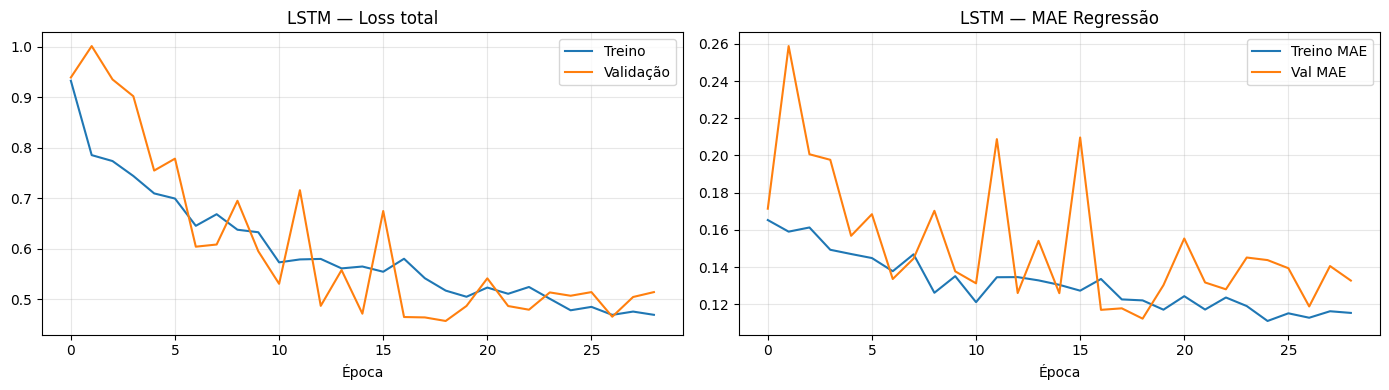

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('LSTM — Loss total')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history.get('regression_mae', []),     label='Treino MAE')
axes[1].plot(history.history.get('val_regression_mae', []), label='Val MAE')
axes[1].set_title('LSTM — MAE Regressão')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.7 Visualização de previsões

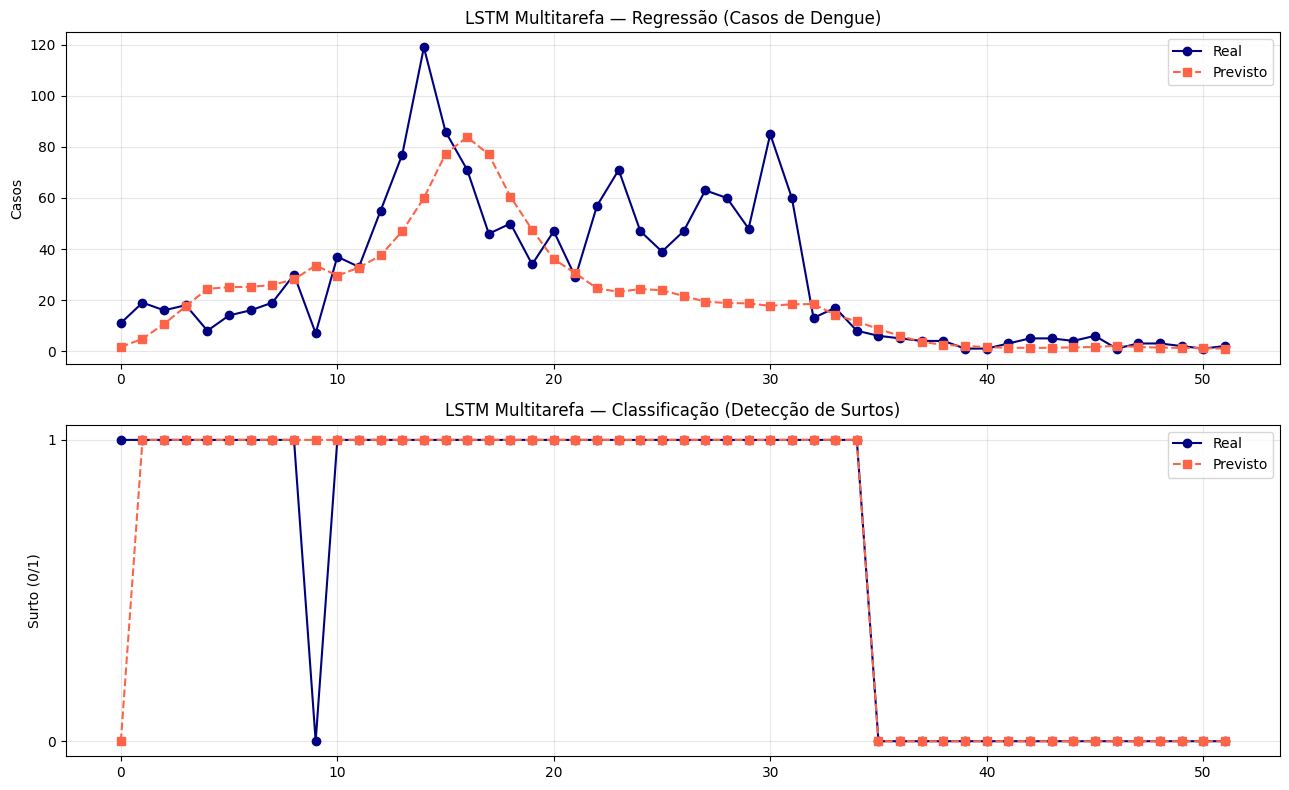

In [112]:
test_index_lstm = df.loc[df['ano'] == 2025].index[:len(y_reg_test_orig)]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(y_reg_test_orig,     label='Real',    marker='o', color='navy')
axes[0].plot(y_pred_lstm_reg,     label='Previsto',marker='s', linestyle='--', color='tomato')
axes[0].set_title('LSTM Multitarefa — Regressão (Casos de Dengue)')
axes[0].set_ylabel('Casos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_class_test,        label='Real',    marker='o', color='navy')
axes[1].plot(y_pred_lstm_class,   label='Previsto',marker='s', linestyle='--', color='tomato')
axes[1].set_title('LSTM Multitarefa — Classificação (Detecção de Surtos)')
axes[1].set_ylabel('Surto (0/1)')
axes[1].set_yticks([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Comparativo Final dos Três Modelos

In [ ]:
# Coleta de resultados 
results = {
    "Modelo": ["SARIMA", "Random Forest", "LSTM Multitarefa"],

    # Regressão
    "MAPE (%)": [
        round(ic_mape_s['media'], 2),
        None,                           
        round(ic_mape_l['media'], 2)
    ],
    "MAPE IC inf (%)": [
        round(ic_mape_s['ic_inferior'], 2),
        None,
        round(ic_mape_l['ic_inferior'], 2)
    ],
    "MAPE IC sup (%)": [
        round(ic_mape_s['ic_superior'], 2),
        None,
        round(ic_mape_l['ic_superior'], 2)
    ],
    "MedAPE (%)": [
        round(ic_medape_s['media'], 2),
        None,
        round(ic_medape_l['media'], 2)
    ],

    # Classificação
    "F1": [
        None,                            
        round(ic_f1_rf['media'], 3),
        round(ic_f1_l['media'], 3)
    ],
    "F1 IC inf": [
        None,
        round(ic_f1_rf['ic_inferior'], 3),
        round(ic_f1_l['ic_inferior'], 3)
    ],
    "F1 IC sup": [
        None,
        round(ic_f1_rf['ic_superior'], 3),
        round(ic_f1_l['ic_superior'], 3)
    ],
    "AUC": [
        None,
        round(ic_auc_rf['media'], 3),
        round(ic_auc_l['media'], 3)
    ],
    "AUC IC inf": [
        None,
        round(ic_auc_rf['ic_inferior'], 3),
        round(ic_auc_l['ic_inferior'], 3)
    ],
    "AUC IC sup": [
        None,
        round(ic_auc_rf['ic_superior'], 3),
        round(ic_auc_l['ic_superior'], 3)
    ],
}

df_results = pd.DataFrame(results).set_index('Modelo')
print("Tabela comparativa de métricas (IC 95% via bootstrap) ")
df_results

=== Tabela comparativa de métricas (IC 95% via bootstrap) ===


,MAPE (%),MAPE IC inf (%),MAPE IC sup (%),MedAPE (%),F1,F1 IC inf,F1 IC sup,AUC,AUC IC inf,AUC IC sup
Modelo,,,,,,,,,,
SARIMA,77.13,62.17,98.31,68.32,NaN,NaN,NaN,NaN,NaN,NaN
Random Forest,NaN,NaN,NaN,NaN,0.924,0.847,0.984,0.939,0.830,1.0
LSTM Multitarefa,56.11,43.30,73.23,49.04,0.970,0.921,1.000,0.954,0.849,1.0


### 6.1 Gráfico comparativo — Regressão (MAPE)

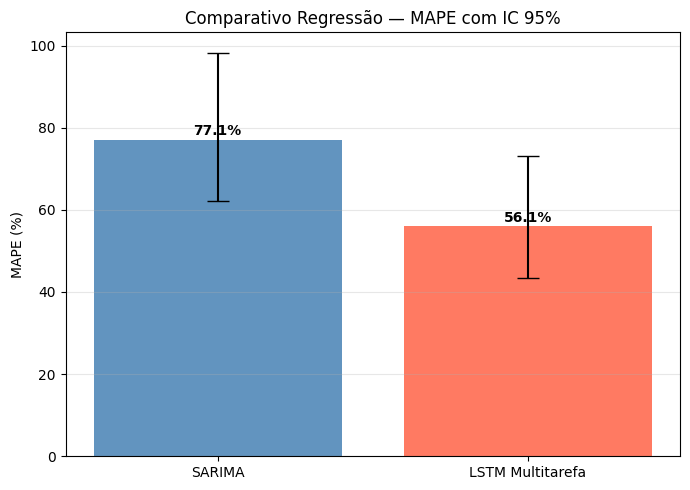

In [114]:
modelos_reg   = ['SARIMA', 'LSTM Multitarefa']
mape_vals     = [ic_mape_s['media'],   ic_mape_l['media']]
mape_err_inf  = [ic_mape_s['media'] - ic_mape_s['ic_inferior'],
                 ic_mape_l['media'] - ic_mape_l['ic_inferior']]
mape_err_sup  = [ic_mape_s['ic_superior'] - ic_mape_s['media'],
                 ic_mape_l['ic_superior'] - ic_mape_l['media']]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(modelos_reg, mape_vals,
              yerr=[mape_err_inf, mape_err_sup],
              capsize=8, color=['steelblue', 'tomato'], alpha=0.85)
ax.set_ylabel('MAPE (%)')
ax.set_title('Comparativo Regressão — MAPE com IC 95%')
for bar, val in zip(bars, mape_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Gráfico comparativo — Classificação (F1 e AUC)

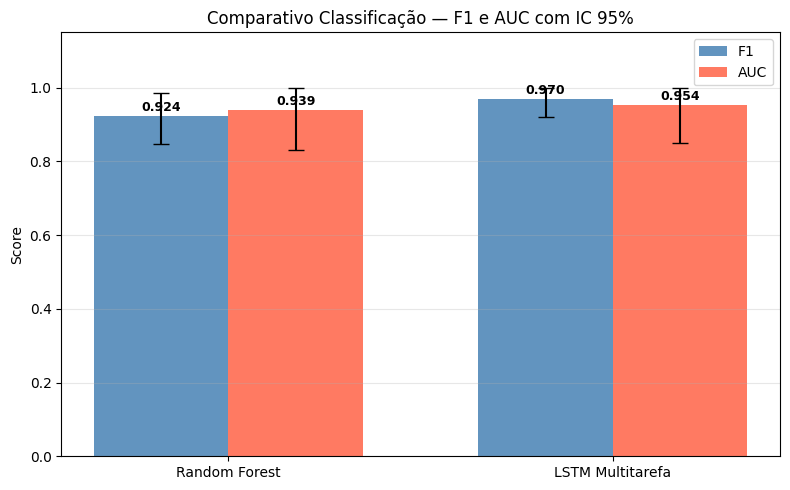

In [115]:
modelos_cls  = ['Random Forest', 'LSTM Multitarefa']
f1_vals      = [ic_f1_rf['media'],  ic_f1_l['media']]
auc_vals     = [ic_auc_rf['media'], ic_auc_l['media']]

f1_err  = [[ic_f1_rf['media']  - ic_f1_rf['ic_inferior'],  ic_f1_l['media']  - ic_f1_l['ic_inferior']],
           [ic_f1_rf['ic_superior'] - ic_f1_rf['media'],    ic_f1_l['ic_superior'] - ic_f1_l['media']]]
auc_err = [[ic_auc_rf['media'] - ic_auc_rf['ic_inferior'], ic_auc_l['media'] - ic_auc_l['ic_inferior']],
           [ic_auc_rf['ic_superior'] - ic_auc_rf['media'],  ic_auc_l['ic_superior'] - ic_auc_l['media']]]

x = np.arange(len(modelos_cls))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, f1_vals,  w, yerr=f1_err,  capsize=6,
            label='F1',  color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, auc_vals, w, yerr=auc_err, capsize=6,
            label='AUC', color='tomato',    alpha=0.85)

for bar, val in zip(list(b1)+list(b2), f1_vals+auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(modelos_cls)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Comparativo Classificação — F1 e AUC com IC 95%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Painel comparativo de previsões — todos os modelos

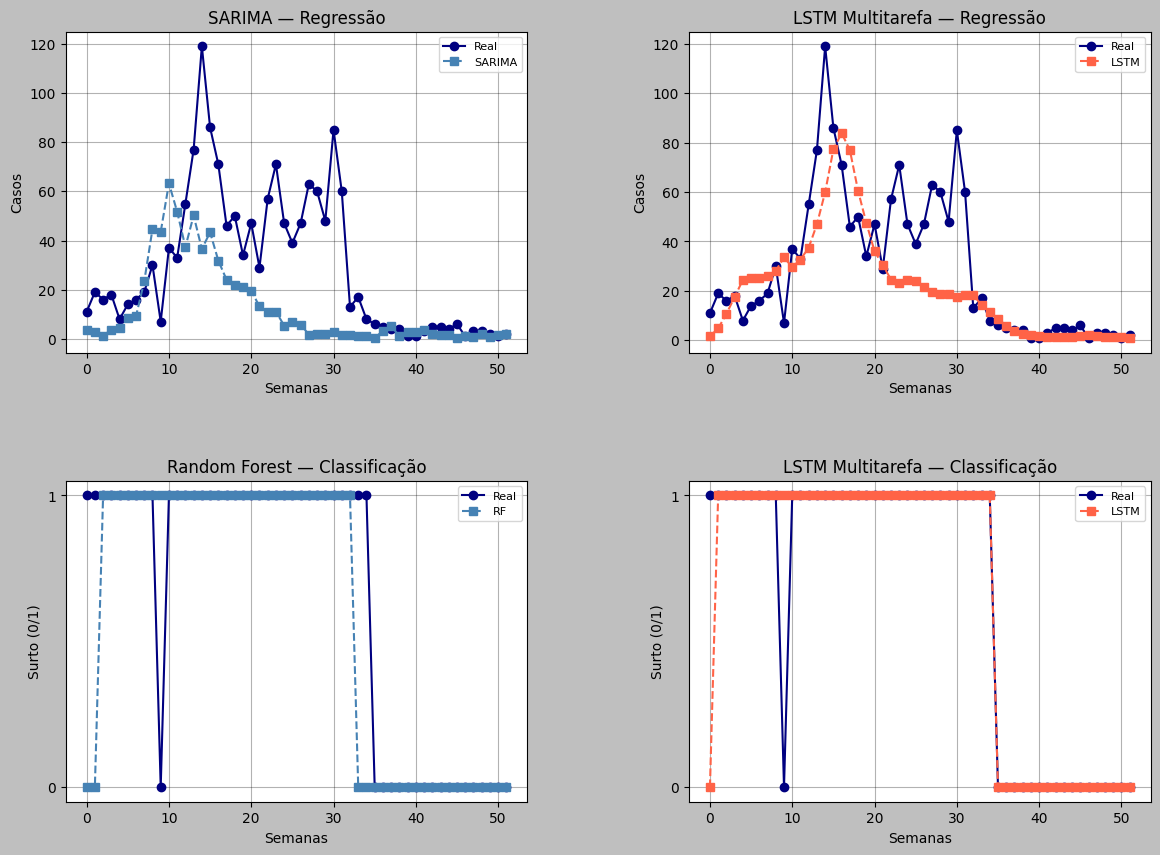

In [ ]:
n_test = min(len(y_test_s), len(y_pred_lstm_reg), len(y_reg_test_orig))
idx = range(n_test)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(idx, y_test_s.values[:n_test],  label='Real',    color='navy',  marker='o')
ax0.plot(idx, y_pred_s[:n_test],          label='SARIMA',  color='steelblue', marker='s', linestyle='--')
ax0.set_title('SARIMA — Regressão')
ax0.set_xlabel('Semanas')
ax0.set_ylabel('Casos')
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(idx, y_reg_test_orig[:n_test],   label='Real',    color='navy',  marker='o')
ax1.plot(idx, y_pred_lstm_reg[:n_test],   label='LSTM',    color='tomato',marker='s', linestyle='--')
ax1.set_title('LSTM Multitarefa — Regressão')
ax1.set_xlabel('Semanas')
ax1.set_ylabel('Casos')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(idx, y_test_rf[:n_test],         label='Real',    color='navy',  marker='o')
ax2.plot(idx, y_pred_rf[:n_test],          label='RF',      color='steelblue', marker='s', linestyle='--')
ax2.set_title('Random Forest — Classificação')
ax2.set_xlabel('Semanas')
ax2.set_ylabel('Surto (0/1)')
ax2.set_yticks([0, 1])
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(idx, y_class_test[:n_test],      label='Real',    color='navy',  marker='o')
ax3.plot(idx, y_pred_lstm_class[:n_test], label='LSTM',    color='tomato',marker='s', linestyle='--')
ax3.set_title('LSTM Multitarefa — Classificação')
ax3.set_xlabel('Semanas')
ax3.set_ylabel('Surto (0/1)')
ax3.set_yticks([0, 1])
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
plt.show()

## 6.4 Versão do painel em greyscale:

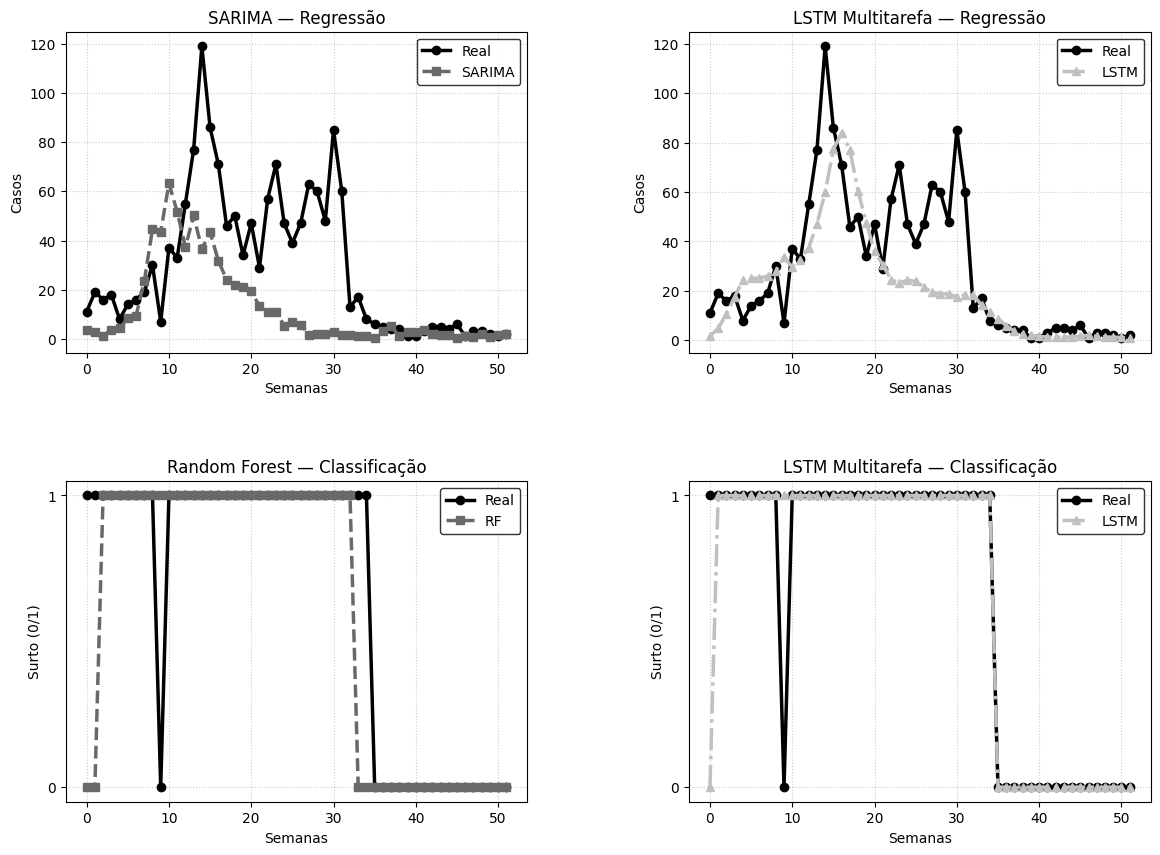

In [130]:
n_test = min(len(y_test_s), len(y_pred_lstm_reg), len(y_reg_test_orig))
idx = range(n_test)

plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor('white')

ax0.plot(
    idx,
    y_test_s.values[:n_test],
    label='Real',
    color='black',
    marker='o',
    linestyle='-',
    linewidth=2.5,
    markersize=6
)

ax0.plot(
    idx,
    y_pred_s[:n_test],
    label='SARIMA',
    color='dimgray',
    marker='s',
    linestyle='--',
    linewidth=2.5,
    markersize=6
)

ax0.set_title('SARIMA — Regressão', fontsize=12)
ax0.set_xlabel('Semanas', fontsize=10)
ax0.set_ylabel('Casos', fontsize=10)

ax0.legend(
    fontsize=10,
    frameon=True,
    edgecolor='black'
)

ax0.grid(
    True,
    linestyle=':',
    alpha=0.2
)

ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor('white')

ax1.plot(
    idx,
    y_reg_test_orig[:n_test],
    label='Real',
    color='black',
    marker='o',
    linestyle='-',
    linewidth=2.5,
    markersize=6
)

ax1.plot(
    idx,
    y_pred_lstm_reg[:n_test],
    label='LSTM',
    color='silver',
    marker='^',
    linestyle='-.',
    linewidth=2.5,
    markersize=6
)

ax1.set_title('LSTM Multitarefa — Regressão', fontsize=12)
ax1.set_xlabel('Semanas', fontsize=10)
ax1.set_ylabel('Casos', fontsize=10)

ax1.legend(
    fontsize=10,
    frameon=True,
    edgecolor='black'
)

ax1.grid(
    True,
    linestyle=':',
    alpha=0.2
)

ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('white')

ax2.plot(
    idx,
    y_test_rf[:n_test],
    label='Real',
    color='black',
    marker='o',
    linestyle='-',
    linewidth=2.5,
    markersize=6
)

ax2.plot(
    idx,
    y_pred_rf[:n_test],
    label='RF',
    color='dimgray',
    marker='s',
    linestyle='--',
    linewidth=2.5,
    markersize=6
)

ax2.set_title('Random Forest — Classificação', fontsize=12)
ax2.set_xlabel('Semanas', fontsize=10)
ax2.set_ylabel('Surto (0/1)', fontsize=10)

ax2.set_yticks([0, 1])

ax2.legend(
    fontsize=10,
    frameon=True,
    edgecolor='black'
)

ax2.grid(
    True,
    linestyle=':',
    alpha=0.2
)

ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('white')

ax3.plot(
    idx,
    y_class_test[:n_test],
    label='Real',
    color='black',
    marker='o',
    linestyle='-',
    linewidth=2.5,
    markersize=6
)

ax3.plot(
    idx,
    y_pred_lstm_class[:n_test],
    label='LSTM',
    color='silver',
    marker='^',
    linestyle='-.',
    linewidth=2.5,
    markersize=6
)

ax3.set_title('LSTM Multitarefa — Classificação', fontsize=12)
ax3.set_xlabel('Semanas', fontsize=10)
ax3.set_ylabel('Surto (0/1)', fontsize=10)

ax3.set_yticks([0, 1])

ax3.legend(
    fontsize=10,
    frameon=True,
    edgecolor='black'
)

ax3.grid(
    True,
    linestyle=':',
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "desempenhos-modelos-tcc2-gray.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()




## 7. Sumário final

In [132]:

print(f"\n[SARIMA]")
print(f"  MAPE  : {ic_mape_s['media']:.2f}% [{ic_mape_s['ic_inferior']:.2f}%, {ic_mape_s['ic_superior']:.2f}%]")
print(f"  MedAPE: {ic_medape_s['media']:.2f}% [{ic_medape_s['ic_inferior']:.2f}%, {ic_medape_s['ic_superior']:.2f}%]")
print(f"\n[Random Forest]")
print(f"  F1 : {ic_f1_rf['media']:.3f} [{ic_f1_rf['ic_inferior']:.3f}, {ic_f1_rf['ic_superior']:.3f}]")
print(f"  AUC: {ic_auc_rf['media']:.3f} [{ic_auc_rf['ic_inferior']:.3f}, {ic_auc_rf['ic_superior']:.3f}]")
print(f"\n[LSTM Multitarefa Bidirecional]")
print(f"  MAPE  : {ic_mape_l['media']:.2f}% [{ic_mape_l['ic_inferior']:.2f}%, {ic_mape_l['ic_superior']:.2f}%]")
print(f"  MedAPE: {ic_medape_l['media']:.2f}% [{ic_medape_l['ic_inferior']:.2f}%, {ic_medape_l['ic_superior']:.2f}%]")
print(f"  F1    : {ic_f1_l['media']:.3f} [{ic_f1_l['ic_inferior']:.3f}, {ic_f1_l['ic_superior']:.3f}]")
print(f"  AUC   : {ic_auc_l['media']:.3f} [{ic_auc_l['ic_inferior']:.3f}, {ic_auc_l['ic_superior']:.3f}]")


[SARIMA]
  MAPE  : 77.13% [62.17%, 98.31%]
  MedAPE: 68.32% [55.69%, 81.49%]

[Random Forest]
  F1 : 0.924 [0.847, 0.984]
  AUC: 0.939 [0.830, 1.000]

[LSTM Multitarefa Bidirecional]
  MAPE  : 56.11% [43.30%, 73.23%]
  MedAPE: 49.04% [38.92%, 57.19%]
  F1    : 0.970 [0.921, 1.000]
  AUC   : 0.954 [0.849, 1.000]
